In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('student_habits_performance.csv')

In [3]:
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   object 
 12  internet_quality               1000 non-null   ob

In [5]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [6]:
data.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [7]:
data.select_dtypes(include=('int64','float64')).columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [8]:
X = data.drop(['student_id', 'exam_score','gender','diet_quality','parental_education_level','internet_quality','extracurricular_participation','part_time_job'], axis=1)
y = data['exam_score']

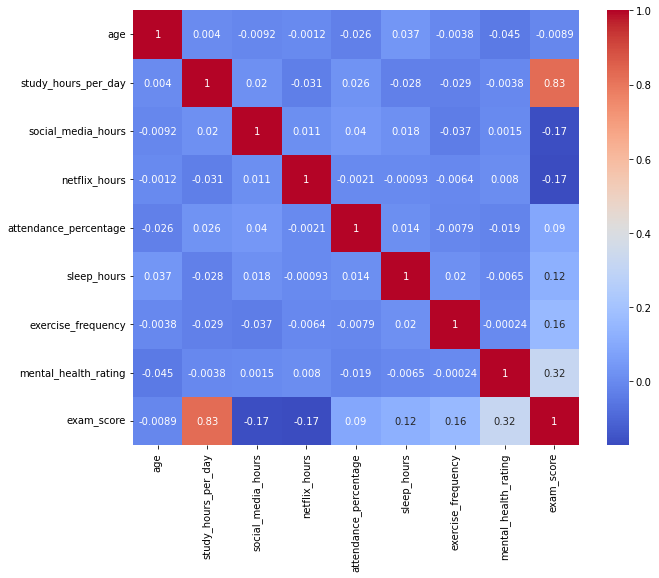

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

Study Hours per Day has the highest positive correlation (0.83) with Exam Score, indicating that students who study more tend to achieve higher scores.
Mental Health Rating shows a moderate positive relationship (0.32) with Exam Score.
Social Media Hours and Netflix Hours have weak negative correlations (-0.17), suggesting that excessive entertainment time may slightly reduce exam performance.
Age has almost no relationship with Exam Score.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3 , random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
lr.coef_

array([ 0.06960354,  9.59188927, -2.74450869, -2.37359222,  0.1459774 ,
        2.02307756,  1.27787585,  1.94070414])

In [14]:
lr.intercept_

5.675772892516207

In [15]:
y_pred_train =lr.predict(X_train)

In [16]:
from sklearn.metrics import (mean_absolute_error , mean_squared_error ,r2_score)

In [17]:
mae = mean_absolute_error(y_train,y_pred_train)
mse = mean_squared_error (y_train,y_pred_train)
rmse = mse ** 0.5
r2 = r2_score(y_train,y_pred_train)

print("MAE:" , mae)
print ("MSE:" ,mse)
print("RMSE:" , rmse)
print("R2 Score:",r2)

MAE: 4.219233116263186
MSE: 28.48452021343859
RMSE: 5.33708911424932
R2 Score: 0.9010117069230436


In [18]:
y_pred_test =lr.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test,y_pred_test)
mse = mean_squared_error (y_test,y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred_test)

print("MAE:" , mae)
print ("MSE:" ,mse)
print("RMSE:" , rmse)
print("R2 Score:",r2)

MAE: 4.229445241943834
MSE: 28.233184730941794
RMSE: 5.313490823455123
R2 Score: 0.8983545515482991


In [20]:
result = pd.DataFrame({
    "Actual": y_test,
    "Preidicted":y_pred_test})
result.head()

,Actual,Preidicted
521,64.2,66.438797
737,72.7,74.824270
740,79.0,78.422311
660,79.5,74.603377
411,58.2,61.524044


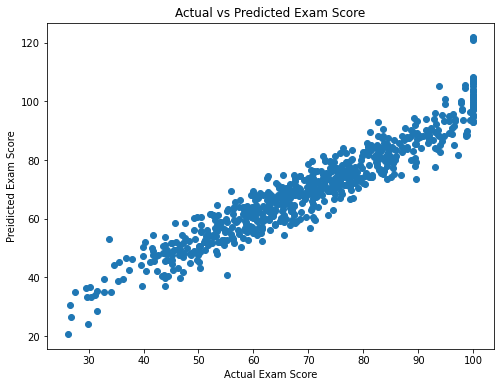

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_train,y_pred_train)
plt.xlabel("Actual Exam Score")
plt.ylabel("Preidicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

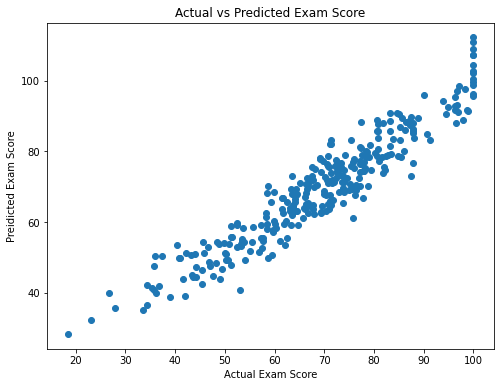

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_test)
plt.xlabel("Actual Exam Score")
plt.ylabel("Preidicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

In [30]:
study_hours = float(input("Enter Study Hours Per Day: "))
attendance = float(input("Enter Attendance Percentage: "))
sleep = float(input("Enter Sleep Hours: "))
exercise = float(input("Enter Exercise Frequency: "))
mental_health = float(input("Enter Mental Health Rating (1-10): "))
social_media = float(input("Enter Social Media Hours: "))
netflix = float(input("Enter Netflix Hours: "))
age = int(input("Enter Age: "))

new_student = pd.DataFrame({
    'age': [age],
    'study_hours_per_day': [study_hours],
    'social_media_hours': [social_media],
    'netflix_hours': [netflix],
    'attendance_percentage': [attendance],
    'sleep_hours': [sleep],
    'exercise_frequency': [exercise],
    'mental_health_rating': [mental_health]
})

predicted_score = lr.predict(new_student)

print("Predicted Exam Score:", predicted_score[0])

Enter Study Hours Per Day:  5
Enter Attendance Percentage:  80
Enter Sleep Hours:  7
Enter Exercise Frequency:  5
Enter Mental Health Rating (1-10):  8
Enter Social Media Hours:  3
Enter Netflix Hours:  2
Enter Age:  20


Predicted Exam Score: 89.80132702220784


In [31]:
import joblib

In [33]:
joblib.dump(lr,'student_perfomance_predictor.joblib')

['student_perfomance_predictor.joblib']